# RECOVAR Demo

This demo consists of three parts:

1. **Continuous MSEED scoring with RECOVAR** read a real 3-component MiniSEED file with ObsPy, slide a 30 s window across it, and plot the earthquake score over time.
2. **Single window** score one earthquake window and one noise window on their own
3. **Labeled benchmark** run the classifier on a labeled test set and plot the ROC/AUC.

The MSEED data is `data/test.mseed`: 450 s of `KO.DKL..HH?` at 100 Hz around the M6.1 Bigadiç–Balıkesir 2025 earthquake. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from scipy.signal import detrend, resample

from recovar.representation_learning_models import RepresentationLearningMultipleAutoencoder
from recovar.classifier_models import ClassifierMultipleAutoencoder
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
# MiniSEED data and sliding-window parameters
MSEED_PATH  = "data/test.mseed"
STEP_SIZE_SECONDS = 10.0   # sliding-window step
THRESHOLD   = 0.5    # detection threshold score ([0-1])

# RECOVAR preprocessing / model constants
WINDOW_SIZE_SECONDS   = 30.0   # RECOVAR scores 30 s windows
PREPROCESSING_PADDING = 5.0    # s cut from each end to drop filter edge effects
FREQMIN, FREQMAX = 1.0, 20.0   # bandpass corners (Hz)

MODEL_PATH  = "models/representation_cross_covariances.h5"

Preprocess function used to preprocess MSEED files

In [ ]:
TARGET_FS = 100   # resample everything to 100 Hz

def preprocess(data, fs):
    """Resample to 100 Hz, then demean, linear-detrend, and 1-20 Hz bandpass one channel (a 1-D array).
    """
    if fs != TARGET_FS:
        data = resample(data, int(len(data) * TARGET_FS / fs))
    data = detrend(data - data.mean(), type="linear")
    freqs = np.fft.fftfreq(len(data), d=1.0 / TARGET_FS)
    spectrum = np.fft.fft(data)
    spectrum[(np.abs(freqs) < FREQMIN) | (np.abs(freqs) > FREQMAX)] = 0
    return np.real(np.fft.ifft(spectrum)).astype(np.float32)

## Part 1: Continuous scoring

Read the file with ObsPy and plot it natively. Then preprocess each component,
slide a 30 s window across the trace, score every window, and plot the score over
time. It should rise sharply at the P arrival and decay through the coda.

3 Trace(s) in Stream:
KO.DKL..HHE | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples
KO.DKL..HHN | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples
KO.DKL..HHZ | 2025-08-10T16:53:04.960000Z - 2025-08-10T17:00:34.950000Z | 100.0 Hz, 45000 samples


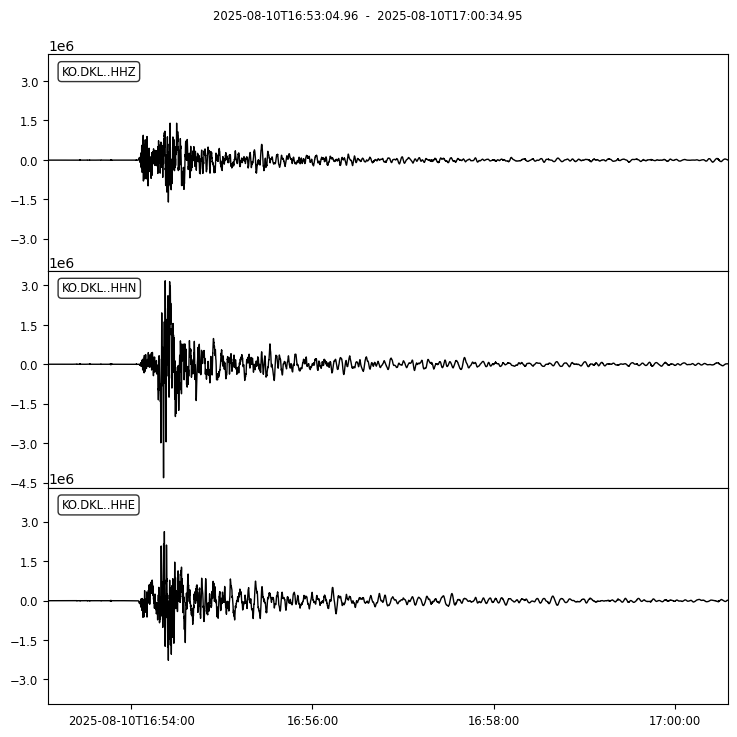

In [4]:
st = obspy.read(MSEED_PATH)
st.merge(method=1, fill_value=0)
print(st)

st.plot();

In [ ]:
# Pull the three components (RECOVAR expects channel order Z, N, E).
z = st.select(channel="*Z")[0]
n = st.select(channel="*N")[0]
e = st.select(channel="*E")[0]
t0 = z.stats.starttime
fs = z.stats.sampling_rate   # 100 Hz for this stream

pad_samples = int(PREPROCESSING_PADDING * fs)   # padding in samples for slicing

# Preprocess each channel (demean + detrend + 1-20 Hz), then trim 5 s off each end to drop filter edge effects.
# The first scored sample is at t0 + 5 s.
channels = {}
for name, trace in (("z", z), ("n", n), ("e", e)):
    filtered = preprocess(trace.data.astype(np.float32), fs)
    channels[name] = filtered[pad_samples:-pad_samples]   # drop filter edge effects

z_preprocessed = channels["z"]
n_preprocessed = channels["n"]
e_preprocessed = channels["e"]

trim_start = t0 + PREPROCESSING_PADDING

In [ ]:
# Build the RECOVAR classifier 
window_samples = int(WINDOW_SIZE_SECONDS * fs)   # window length in samples (model input)

model = RepresentationLearningMultipleAutoencoder(
    name="rep_learning_autoencoder_ensemble", input_noise_std=1e-6, eps=1e-27)
model.compile()
model(np.zeros((1, window_samples, 3), dtype=np.float32))   # initialize the model with correct input shape
model.load_weights(MODEL_PATH)

classifier = ClassifierMultipleAutoencoder(model)

In [ ]:
# Slide a 30 s (window_samples-sample) window with a STEP_SIZE_SECONDS step.
step_samples       = int(STEP_SIZE_SECONDS * fs)
n_windows          = (len(z_preprocessed) - window_samples) // step_samples + 1
waveform_windows   = np.empty((n_windows, window_samples, 3), dtype=np.float32)
window_start_times = []
for i in range(n_windows):
    s = i * step_samples
    waveform_windows[i, :, 0] = z_preprocessed[s:s + window_samples]
    waveform_windows[i, :, 1] = n_preprocessed[s:s + window_samples]
    waveform_windows[i, :, 2] = e_preprocessed[s:s + window_samples]
    window_start_times.append(float((trim_start + s / fs) - t0))   # window start, s from stream start

# Score every 30 s window in the stream in one call to the RECOVAR classifier (one score in [0, 1] per window).
window_scores = classifier(waveform_windows)

print(f"Scored {n_windows} windows  (step={STEP_SIZE_SECONDS:.0f}s, window={WINDOW_SIZE_SECONDS:.0f}s)")
print(f"Score range: {window_scores.min():.4f} - {window_scores.max():.4f}")

In [ ]:
# Plot RECOVAR scores over the MSEED stream
window_start_times   = np.asarray(window_start_times)
window_scores        = np.asarray(window_scores)
is_above_threshold   = window_scores >= THRESHOLD

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(window_start_times, window_scores, 0, color="#4C72B0", alpha=0.15)
ax.plot(window_start_times, window_scores, "-o", color="#4C72B0", linewidth=1.8, markersize=5, label="RECOVAR score")
ax.scatter(window_start_times[is_above_threshold], window_scores[is_above_threshold], s=70, color="#C44E52", zorder=3, label="Detection")
ax.axhline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"Threshold = {THRESHOLD}")
ax.set_xlim(window_start_times[0] - 2, window_start_times[-1] + 2)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Window start (s from stream start)", fontsize=11)
ax.set_ylabel("Earthquake probability", fontsize=11)
ax.set_title("RECOVAR scores over test MiniSEED", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Part 2: Score a single window

Slice and score only one window (30 seconds) from the stream. 
Slice the window out of the stream Pad 5 s on each side so the bandpass filter's edge effects fall outside the part we keep.

### Scoring an Earthquake window

In [ ]:
# Pick the 30 s window to score. here we choose the window over the P arrival of the M6.1 earthquake 
earthquake_window_start = obspy.UTCDateTime("2025-08-10T16:53:51.96")

# Slice the window with PREPROCESSING_PADDING seconds on each side so the bandpass
# filter's edge effects fall outside the part we keep.
win_eq = st.slice(earthquake_window_start - PREPROCESSING_PADDING, earthquake_window_start + WINDOW_SIZE_SECONDS + PREPROCESSING_PADDING)

# Preprocess each channel, then keep the WINDOW_SIZE_SECONDS span after the padding.
eq_window = {}
for c in "ZNE":
    filtered = preprocess(win_eq.select(channel=f"*{c}")[0].data.astype(np.float32), fs)
    eq_window[c] = filtered[pad_samples:pad_samples + window_samples]

z_eq_window = eq_window["Z"]
n_eq_window = eq_window["N"]
e_eq_window = eq_window["E"]

# Score the window 
waveform = np.stack([z_eq_window, n_eq_window, e_eq_window], axis=-1)[np.newaxis]   # (1, 3000, 3) the classifier wants a batch of (3000, 3) windows, so add a batch axis
score_eq = float(classifier(waveform)[0])

print(f"Earthquake window starting {earthquake_window_start}")
print(f"RECOVAR earthquake score: {score_eq:.4f}")

In [ ]:
# Plot the window
eq_traces = obspy.Stream([
    obspy.Trace(data, header={"sampling_rate": TARGET_FS, "starttime": earthquake_window_start, "channel": f"HH{c}"})
    for c, data in zip("ZNE", (z_eq_window, n_eq_window, e_eq_window))
])

print(f"RECOVAR score = {score_eq:.3f}  (earthquake)")
eq_traces.plot();

### Scoring a Noise window

In [ ]:
noise_window_start = obspy.UTCDateTime("2025-08-10T16:58:21.96")

noise_window = st.slice(noise_window_start - PREPROCESSING_PADDING, noise_window_start + WINDOW_SIZE_SECONDS + PREPROCESSING_PADDING)

# Preprocess each channel, then keep the WINDOW_SIZE_SECONDS span after the padding.
noise_window_channels = {}
for c in "ZNE":
    filtered = preprocess(noise_window.select(channel=f"*{c}")[0].data.astype(np.float32), fs)
    noise_window_channels[c] = filtered[pad_samples:pad_samples + window_samples]

z_noise_window = noise_window_channels["Z"]
n_noise_window = noise_window_channels["N"]
e_noise_window = noise_window_channels["E"]

waveform = np.stack([z_noise_window, n_noise_window, e_noise_window], axis=-1)[np.newaxis]   # (1, 3000, 3)
score_noise = float(classifier(waveform)[0])

print(f"Noise window starting {noise_window_start}")
print(f"RECOVAR earthquake score: {score_noise:.4f}")

In [ ]:
# Plot the already-preprocessed window (no second preprocessing).
noise_traces = obspy.Stream([
    obspy.Trace(data, header={"sampling_rate": TARGET_FS, "starttime": noise_window_start, "channel": f"HH{c}"})
    for c, data in zip("ZNE", (z_noise_window, n_noise_window, e_noise_window))
])

print(f"RECOVAR score = {score_noise:.3f}  (noise)")
noise_traces.plot();

## Part 3: Labeled benchmark (ROC / AUC)

Run the same RECOVAR classifier on the labeled test set and plot the ROC
curve. 

It returns an earthquake probability per sample.

Data used here is `data/X_test_1280sample.npy` and `data/Y_test_1280sample.npy`

In [13]:
# Reuse the classifier built in Part 1 on the labeled test set.
TEST_DATA_PATH  = "data/X_test_1280sample.npy"
TEST_LABEL_PATH = "data/Y_test_1280sample.npy"

X_test = np.load(TEST_DATA_PATH)
Y_test = np.load(TEST_LABEL_PATH)
print(f"Test data:  {X_test.shape}")
print(f"Test labels: {Y_test.shape}")

Test data:  (1280, 3000, 3)
Test labels: (1280,)


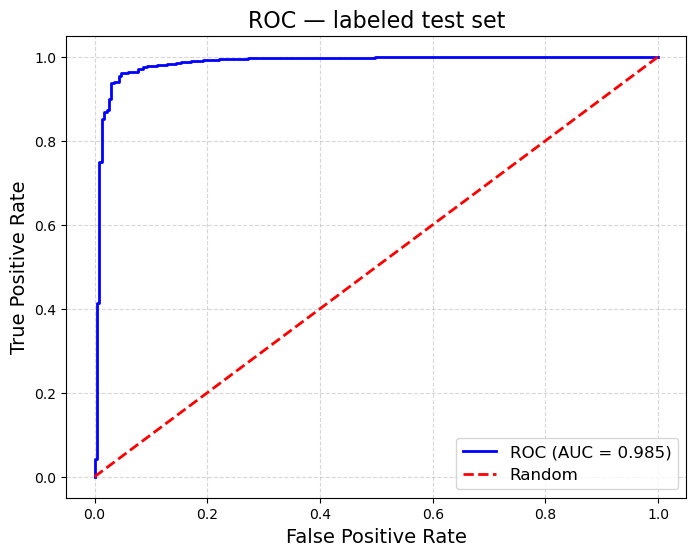

In [14]:
earthquake_scores = classifier(X_test)

fpr, tpr, _ = roc_curve(Y_test, earthquake_scores)
auc = roc_auc_score(Y_test, earthquake_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC — labeled test set", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()